# 001 — Preparação e visualização de dados para regressão

Sempre importante começar avaliando o dado e depois aplicando o QC nos dados:

1. o significado e a disponibilidade de cada curva;
2. onde e por que faltam medidas;
3. quem seria excluído por uma regra automática;
4. se um valor extremo é ruído, efeito de poço ou geologia;
5. como os preditores se relacionam com `DTC`.

Só então criaremos uma base reprodutível para recuperar `DTC` (µs/ft).

## Mapa mental da preparação

```text
dado bruto
   ↓ entender metadados e cobertura
diagnóstico de ausências e extremos
   ↓ comparar consequências das decisões
QC dos dados
   ↓ separar por poço antes de ajustar qualquer estatística
pipeline: input → Pré-processamento → regressão
```

O objetivo é produzir uma tabela de dados adequada à aplicação dos algoritmos de regressão, e não realizar um controle de qualidade (QC) completo voltado à interpretação dos perfis.

In [6]:
from pathlib import Path
import io
import json
import subprocess
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:
    display = print

SEED = 42
rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

## Configuração online

O Drive é montado para que dados, configurações e resultados sobrevivam ao
encerramento do Colab. Se `dataset.csv` ainda não estiver na pasta do curso, ele
será baixado automaticamente usando a mesma fonte do curso de classificação.

In [7]:
from pathlib import Path
import subprocess
import sys

try:
    from google.colab import drive
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

if EM_COLAB:
    drive.mount("/content/drive")
    PASTA_CURSO = Path("/content/drive/MyDrive/Curso_Regressao_Pocos")
else:
    # Permite testar o mesmo notebook fora do Colab.
    PASTA_CURSO = Path.cwd()

PASTA_DADOS = PASTA_CURSO / "dados"
PASTA_SAIDAS = PASTA_CURSO / "saidas"
PASTA_DADOS.mkdir(parents=True, exist_ok=True)
PASTA_SAIDAS.mkdir(parents=True, exist_ok=True)

ID_DADOS_DRIVE = "1u6_1ZMPIDy-agKZnKVUCp0t0bvK8ccPC"
candidatos_dados = [
    PASTA_DADOS / "dataset.csv",
    PASTA_CURSO / "dataset.csv",
    PASTA_CURSO / "dataset(1).csv",
]
ARQUIVO_DADOS = next((p for p in candidatos_dados if p.exists()), None)

if ARQUIVO_DADOS is None:
    try:
        import gdown
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
        import gdown

    ARQUIVO_DADOS = PASTA_DADOS / "dataset.csv"
    gdown.download(id=ID_DADOS_DRIVE, output=str(ARQUIVO_DADOS), quiet=False)

if not ARQUIVO_DADOS.exists():
    raise FileNotFoundError("O dataset não foi localizado nem baixado.")

print(f"Ambiente: {'Google Colab' if EM_COLAB else 'local'}")
print(f"Pasta do curso: {PASTA_CURSO}")
print(f"Dataset: {ARQUIVO_DADOS}")

Mounted at /content/drive
Ambiente: Google Colab
Pasta do curso: /content/drive/MyDrive/Curso_Regressao_Pocos
Dataset: /content/drive/MyDrive/Curso_Regressao_Pocos/dados/dataset.csv


## 1. Carregar e reconhecer a estrutura

In [8]:
bruto = pd.read_csv(ARQUIVO_DADOS)

buffer = io.StringIO()
bruto.info(buf=buffer)
print(buffer.getvalue())
display(bruto.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746575 entries, 0 to 746574
Data columns (total 11 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   WELL                              746575 non-null  object 
 1   DEPTH_MD                          746575 non-null  float64
 2   CALI                              708506 non-null  float64
 3   RMED                              724221 non-null  float64
 4   RDEP                              738413 non-null  float64
 5   RHOB                              622971 non-null  float64
 6   GR                                746575 non-null  float64
 7   NPHI                              425137 non-null  float64
 8   DTC                               692120 non-null  float64
 9   FORCE_2020_LITHOFACIES_LITHOLOGY  746575 non-null  int64  
 10  GROUP                             746497 non-null  object 
dtypes: float64(8), int64(1), object(2)
memory usage: 62.

,WELL,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,FORCE_2020_LITHOFACIES_LITHOLOGY,GROUP
0,15/9-13,494.528,19.480835,1.611410,1.798681,1.884186,80.200851,NaN,161.131180,65000,NORDLAND GP.
1,15/9-13,494.680,19.468800,1.618070,1.795641,1.889794,79.262886,NaN,160.603470,65000,NORDLAND GP.
2,15/9-13,494.832,19.468800,1.626459,1.800733,1.896523,74.821999,NaN,160.173615,65000,NORDLAND GP.
3,15/9-13,494.984,19.459282,1.621594,1.801517,1.891913,72.878922,NaN,160.149429,65000,NORDLAND GP.
4,15/9-13,495.136,19.453100,1.602679,1.795299,1.880034,71.729141,NaN,160.128342,65000,NORDLAND GP.


In [9]:
catalogo = pd.DataFrame(
    [
        ("WELL", "—", "identificador", "poço; unidade de separação"),
        ("DEPTH_MD", "m", "índice", "profundidade medida"),
        ("CALI", "in", "entrada/QC", "diâmetro do poço"),
        ("RMED", "ohm·m", "entrada", "resistividade média"),
        ("RDEP", "ohm·m", "entrada", "resistividade profunda"),
        ("RHOB", "g/cm³", "entrada", "densidade"),
        ("GR", "gAPI", "entrada", "raios gama"),
        ("NPHI", "v/v", "entrada", "porosidade neutrônica"),
        ("DTC", "µs/ft", "alvo", "tempo de trânsito compressional"),
        ("GROUP", "—", "contexto", "grupo estratigráfico"),
        (
            "FORCE_2020_LITHOFACIES_LITHOLOGY",
            "código",
            "contexto",
            "litologia/fácies rotulada",
        ),
    ],
    columns=["coluna", "unidade", "papel", "significado"],
)
catalogo

,coluna,unidade,papel,significado
0,WELL,—,identificador,poço; unidade de separação
1,DEPTH_MD,m,índice,profundidade medida
2,CALI,in,entrada/QC,diâmetro do poço
3,RMED,ohm·m,entrada,resistividade média
4,RDEP,ohm·m,entrada,resistividade profunda
5,RHOB,g/cm³,entrada,densidade
6,GR,gAPI,entrada,raios gama
7,NPHI,v/v,entrada,porosidade neutrônica
8,DTC,µs/ft,alvo,tempo de trânsito compressional
9,GROUP,—,contexto,grupo estratigráfico


### Grupo, formação e litologia

- **Grupo:** existe no conjunto de dados utilizado.
- **Formação:** existe no conjunto de dados original.
- **Litologia/fácies:** tipo de rocha observado ou interpretado.

As variáveis categóricas, como **Grupo** e **Litologia**, precisam ser convertidas para uma representação numérica antes de serem utilizadas pela maioria dos algoritmos de aprendizado de máquina. Esses modelos normalmente esperam variáveis de entrada no formato `int` ou `float`, e não valores textuais (`string`).

Uma das técnicas mais utilizadas para essa conversão é o **One-Hot Encoding**, que transforma cada categoria em uma nova variável binária, indicando com `0` ou `1` a presença daquela categoria em cada amostra.


In [10]:
df = pd.DataFrame({
    "Profundidade": [100, 110, 120, 130, 140],
    "Grupo": ["A", "A", "B", "B", "C"],
    "Litologia": ["Arenito", "Folhelho", "Arenito", "Calcario", "Folhelho"]
})

df["Grupo_Num"] = pd.factorize(df["Grupo"])[0]
df["Litologia_Num"] = pd.factorize(df["Litologia"])[0]

df

,Profundidade,Grupo,Litologia,Grupo_Num,Litologia_Num
0,100,A,Arenito,0,0
1,110,A,Folhelho,0,1
2,120,B,Arenito,1,0
3,130,B,Calcario,1,2
4,140,C,Folhelho,2,1


In [11]:
LITOLOGIA = {
    30000: "Sandstone",
    65030: "Sandstone/Shale",
    65000: "Shale",
    80000: "Marl",
    74000: "Dolomite",
    70000: "Limestone",
    70032: "Chalk",
    88000: "Halite",
    86000: "Anhydrite",
    99000: "Tuff",
    90000: "Coal",
    93000: "Basement",
}

dados = bruto.copy()
dados["LITH_CODE"] = dados["FORCE_2020_LITHOFACIES_LITHOLOGY"]
dados["LITHOLOGY"] = dados["LITH_CODE"].map(LITOLOGIA).fillna("Unknown")
dados["GROUP"] = dados["GROUP"].fillna("Unknown group")

resumo = pd.DataFrame(
    {
        "tipo": dados.dtypes.astype(str),
        "nulos": dados.isna().sum(),
        "nulos_%": (100 * dados.isna().mean()).round(2),
        "valores_únicos": dados.nunique(dropna=True),
    }
).sort_values("nulos_%", ascending=False)

print(
    f"{len(dados):,} linhas | {dados.WELL.nunique()} poços | "
    f"{dados.GROUP.nunique()} grupos | {dados.LITHOLOGY.nunique()} litologias"
)
resumo

746,575 linhas | 40 poços | 14 grupos | 12 litologias


,tipo,nulos,nulos_%,valores_únicos
NPHI,float64,321438,43.06,409609
RHOB,float64,123604,16.56,570181
DTC,float64,54455,7.29,666197
CALI,float64,38069,5.10,584528
RMED,float64,22354,2.99,712523
RDEP,float64,8162,1.09,725637
WELL,object,0,0.00,40
DEPTH_MD,float64,0,0.00,728923
GR,float64,0,0.00,732907
FORCE_2020_LITHOFACIES_LITHOLOGY,int64,0,0.00,12


## 2. Ausência não é apenas um número: ela tem posição e contexto

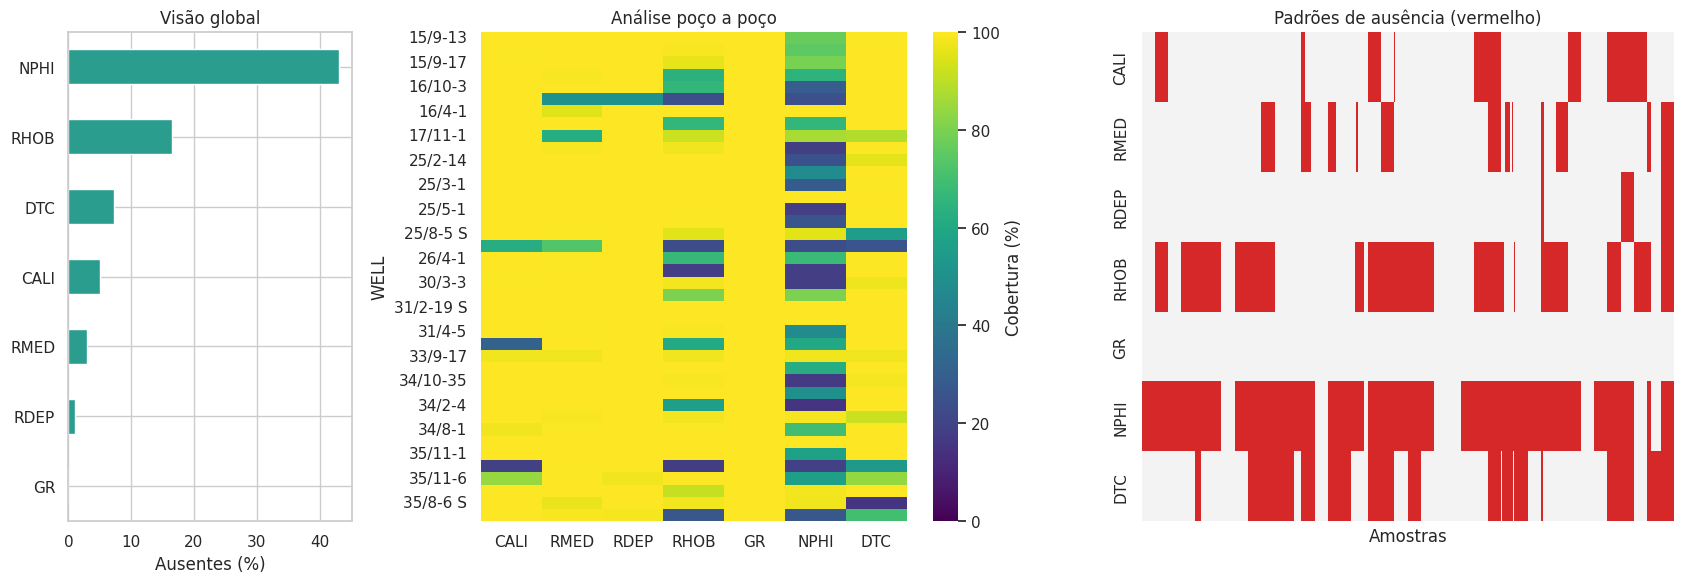

In [12]:
CURVAS = ["CALI", "RMED", "RDEP", "RHOB", "GR", "NPHI", "DTC"]
cobertura_poco = (
    dados.groupby("WELL")[CURVAS]
    .agg(lambda s: 100 * s.notna().mean())
    .round(1)
)

amostra_mapa = (
    dados.sort_values(["WELL", "DEPTH_MD"])
    .groupby("WELL", group_keys=False)
    .head(80)
)

fig, axes = plt.subplots(
    1, 3, figsize=(17, 6), gridspec_kw={"width_ratios": [0.8, 1.5, 1.5]}
)
resumo.loc[CURVAS, "nulos_%"].sort_values().plot.barh(
    ax=axes[0], color="#2a9d8f"
)
axes[0].set(xlabel="Ausentes (%)", ylabel="", title="Visão global")

sns.heatmap(
    cobertura_poco,
    cmap="viridis",
    vmin=0,
    vmax=100,
    ax=axes[1],
    cbar_kws={"label": "Cobertura (%)"},
)
axes[1].set_title("Análise poço a poço")

sns.heatmap(
    amostra_mapa[CURVAS].isna().T,
    cmap=["#f3f3f3", "#d62828"],
    cbar=False,
    xticklabels=False,
    ax=axes[2],
)
axes[2].set(title="Padrões de ausência (vermelho)", xlabel="Amostras")
plt.tight_layout()
plt.show()

**Interpretação:** a ausência de `NPHI`, `RHOB` ou `DTC` ocorre por poço e por
intervalo, não ao acaso. Excluir qualquer linha incompleta pode retirar poços,
grupos ou litologias inteiros. Isso muda o problema que o modelo aprende.

## 3. O custo escondido de `dropna()`

In [13]:
máscaras = {
    "Sem exclusão": pd.Series(True, index=dados.index),
    "Somente DTC conhecido": dados["DTC"].notna(),
    "DTC + GR + RDEP": dados[["DTC", "GR", "RDEP"]].notna().all(axis=1),
    "dropna nas 7 curvas": dados[CURVAS].notna().all(axis=1),
    "dropna em tudo": dados.notna().all(axis=1),
}

linhas_estratégias = []
for nome, máscara in máscaras.items():
    parte = dados.loc[máscara]
    linhas_estratégias.append(
        {
            "estratégia": nome,
            "linhas": len(parte),
            "retido_%": 100 * len(parte) / len(dados),
            "poços": parte["WELL"].nunique(),
            "grupos": parte["GROUP"].nunique(),
            "litologias": parte["LITHOLOGY"].nunique(),
        }
    )

impacto_dropna = pd.DataFrame(linhas_estratégias)
impacto_dropna.round(2)

,estratégia,linhas,retido_%,poços,grupos,litologias
0,Sem exclusão,746575,100.00,40,14,12
1,Somente DTC conhecido,692120,92.71,40,13,12
2,DTC + GR + RDEP,684701,91.71,40,13,12
3,dropna nas 7 curvas,384968,51.56,40,13,12
4,dropna em tudo,384968,51.56,40,13,12


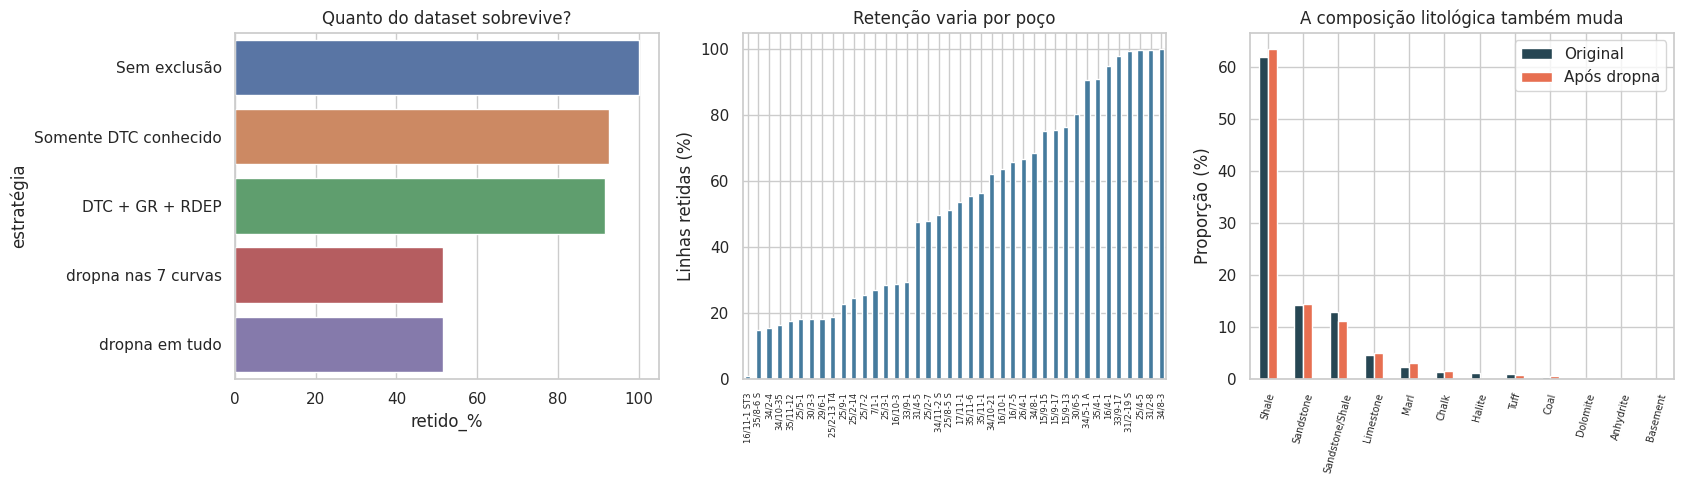

In [14]:
máscara_completa = máscaras["dropna nas 7 curvas"]
retenção_poco = (
    dados.assign(retido=máscara_completa)
    .groupby("WELL")["retido"]
    .mean()
    .mul(100)
    .sort_values()
)

distribuição_original = (
    dados["LITHOLOGY"].value_counts(normalize=True).rename("Original")
)
distribuição_completa = (
    dados.loc[máscara_completa, "LITHOLOGY"]
    .value_counts(normalize=True)
    .rename("Após dropna")
)
dist_lito = (
    pd.concat([distribuição_original, distribuição_completa], axis=1)
    .fillna(0)
    .mul(100)
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.barplot(
    data=impacto_dropna,
    x="retido_%",
    y="estratégia",
    hue="estratégia",
    legend=False,
    ax=axes[0],
)
axes[0].set(title="Quanto do dataset sobrevive?", xlim=(0, 105))

retenção_poco.plot.bar(ax=axes[1], color="#457b9d")
axes[1].set(
    title="Retenção varia por poço",
    ylabel="Linhas retidas (%)",
    xlabel="",
)
axes[1].tick_params(axis="x", labelsize=6)

dist_lito.plot.bar(ax=axes[2], color=["#264653", "#e76f51"])
axes[2].set(
    title="A composição litológica também muda",
    ylabel="Proporção (%)",
    xlabel="",
)
axes[2].tick_params(axis="x", labelsize=7, rotation=75)
plt.tight_layout()
plt.show()

> **Erro comum:** `df.dropna()` parece uma solução neutra, mas seleciona apenas
> os intervalos/poços com conjunto completo de ferramentas. Para regressão:
> removemos do treino apenas as linhas sem o **alvo**; os preditores ausentes
> serão imputados dentro do pipeline. A imputação não “cria verdade”: ela apenas
> permite que o modelo use as outras informações disponíveis.

## 4. Visualizar um poço antes de aplicar regras

In [15]:
CORES_LITOLOGIA = {
    nome: cor
    for nome, cor in zip(
        LITOLOGIA.values(),
        sns.color_palette("tab20", n_colors=len(LITOLOGIA)),
    )
}
CORES_LITOLOGIA["Unknown"] = (0.75, 0.75, 0.75)


def plotar_poco(frame, nome_poco, topo=None, base=None):
    poco = (
        frame.loc[frame["WELL"].eq(nome_poco)]
        .sort_values("DEPTH_MD")
        .copy()
    )
    if topo is not None:
        poco = poco.loc[poco["DEPTH_MD"].ge(topo)]
    if base is not None:
        poco = poco.loc[poco["DEPTH_MD"].le(base)]
    if poco.empty:
        raise ValueError("O poço ou intervalo selecionado não possui dados.")

    fig, axes = plt.subplots(
        1, 6, figsize=(15, 12), sharey=True,
        gridspec_kw={"width_ratios": [1, 1.15, 1, 1, 1, 0.55]},
    )
    axes[0].plot(poco["GR"], poco["DEPTH_MD"], color="forestgreen", lw=0.65)
    axes[0].set(xlabel="GR (gAPI)", ylabel="Profundidade (m)")

    axes[1].semilogx(
        poco["RMED"].where(poco["RMED"] > 0),
        poco["DEPTH_MD"], label="RMED", lw=0.65,
    )
    axes[1].semilogx(
        poco["RDEP"].where(poco["RDEP"] > 0),
        poco["DEPTH_MD"], label="RDEP", lw=0.65,
    )
    axes[1].set_xlabel("Resistividade (ohm·m)")
    axes[1].legend(fontsize=8)

    axes[2].plot(poco["RHOB"], poco["DEPTH_MD"], color="royalblue", lw=0.65)
    axes[2].set_xlabel("RHOB (g/cm³)")
    axes[3].plot(poco["NPHI"], poco["DEPTH_MD"], color="darkorange", lw=0.65)
    axes[3].set_xlabel("NPHI (v/v)")
    axes[4].plot(poco["DTC"], poco["DEPTH_MD"], color="black", lw=0.65)
    axes[4].set_xlabel("DTC (µs/ft)")

    presentes = []
    for litologia, cor in CORES_LITOLOGIA.items():
        mascara = poco["LITHOLOGY"].eq(litologia)
        if mascara.any():
            presentes.append(litologia)
            axes[5].fill_betweenx(
                poco["DEPTH_MD"], 0, 1, where=mascara,
                color=cor, step="mid",
            )
    axes[5].set(xlabel="Litologia", xlim=(0, 1), xticks=[])
    axes[5].legend(
        handles=[
            Patch(facecolor=CORES_LITOLOGIA[nome], label=nome)
            for nome in presentes
        ],
        fontsize=6,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )

    for ax in axes[:5]:
        ax.grid(alpha=0.2)
    axes[0].invert_yaxis()
    fig.suptitle(f"Poço {nome_poco}", y=0.995)
    plt.tight_layout(rect=(0, 0, 0.91, 0.98))
    plt.show()
    return fig


try:
    from ipywidgets import interact
except ImportError:
    interact = None

if interact is not None:
    @interact(nome_poco=sorted(dados["WELL"].unique()))
    def explorar_poco(nome_poco):
        plotar_poco(dados, nome_poco)
else:
    plotar_poco(dados, "15/9-13")

interactive(children=(Dropdown(description='nome_poco', options=('15/9-13', '15/9-15', '15/9-17', '16/10-1', '…

## 5. Boxplot: ferramenta de diagnóstico

Pelo critério clássico, pontos fora de `Q1 − 1,5×IQR` e `Q3 + 1,5×IQR` são
**potenciais extremos estatísticos**. Eles podem representar:

- ruído ou falha de ferramenta;
- efeito de diâmetro/invasão;
- mudança real de litologia ou fluido;
- uma população rara que o modelo precisa aprender.

Portanto, o boxplot sinaliza onde investigar; sozinho não determina exclusão.

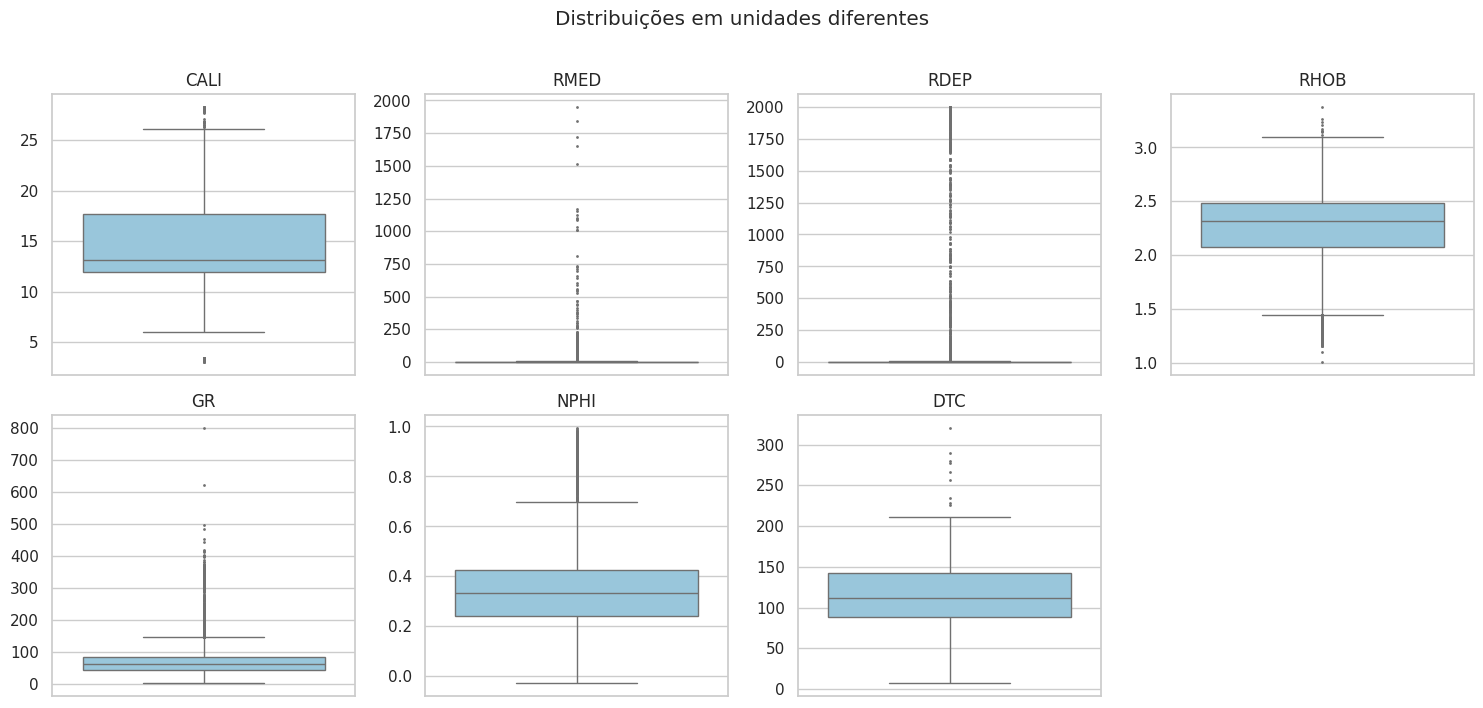

In [16]:
amostra_box = dados.sample(min(80_000, len(dados)), random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, curva in zip(axes.flat, CURVAS):
    sns.boxplot(y=amostra_box[curva], ax=ax, color="#8ecae6", fliersize=1)
    ax.set(title=curva, xlabel="", ylabel="")
axes.flat[-1].axis("off")
fig.suptitle("Distribuições em unidades diferentes", y=1.01)
plt.tight_layout()
plt.show()

In [17]:
linhas_iqr = []
máscara_iqr_ingênua = pd.Series(True, index=dados.index)
limites_iqr = {}

for curva in CURVAS:
    q1, q3 = dados[curva].quantile([0.25, 0.75])
    iqr = q3 - q1
    inferior, superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    limites_iqr[curva] = (inferior, superior)
    fora = dados[curva].notna() & ~dados[curva].between(inferior, superior)
    máscara_iqr_ingênua &= ~fora
    linhas_iqr.append(
        {
            "curva": curva,
            "limite inferior": inferior,
            "limite superior": superior,
            "sinalizados": int(fora.sum()),
            "sinalizados_%": 100 * fora.mean(),
        }
    )

tabela_iqr = pd.DataFrame(linhas_iqr)
display(tabela_iqr.round(3))
print(
    f"Se apagássemos toda linha sinalizada por qualquer boxplot: "
    f"{(~máscara_iqr_ingênua).sum():,} linhas removidas "
    f"({100 * (~máscara_iqr_ingênua).mean():.1f}%)."
)

,curva,limite inferior,limite superior,sinalizados,sinalizados_%
0,CALI,3.429,26.187,984,0.132
1,RMED,-1.574,4.969,93196,12.483
2,RDEP,-1.405,4.726,81879,10.967
3,RHOB,1.447,3.112,6248,0.837
4,GR,-17.906,145.749,24438,3.273
5,NPHI,-0.036,0.701,4224,0.566
6,DTC,6.784,223.992,44,0.006


Se apagássemos toda linha sinalizada por qualquer boxplot: 134,282 linhas removidas (18.0%).


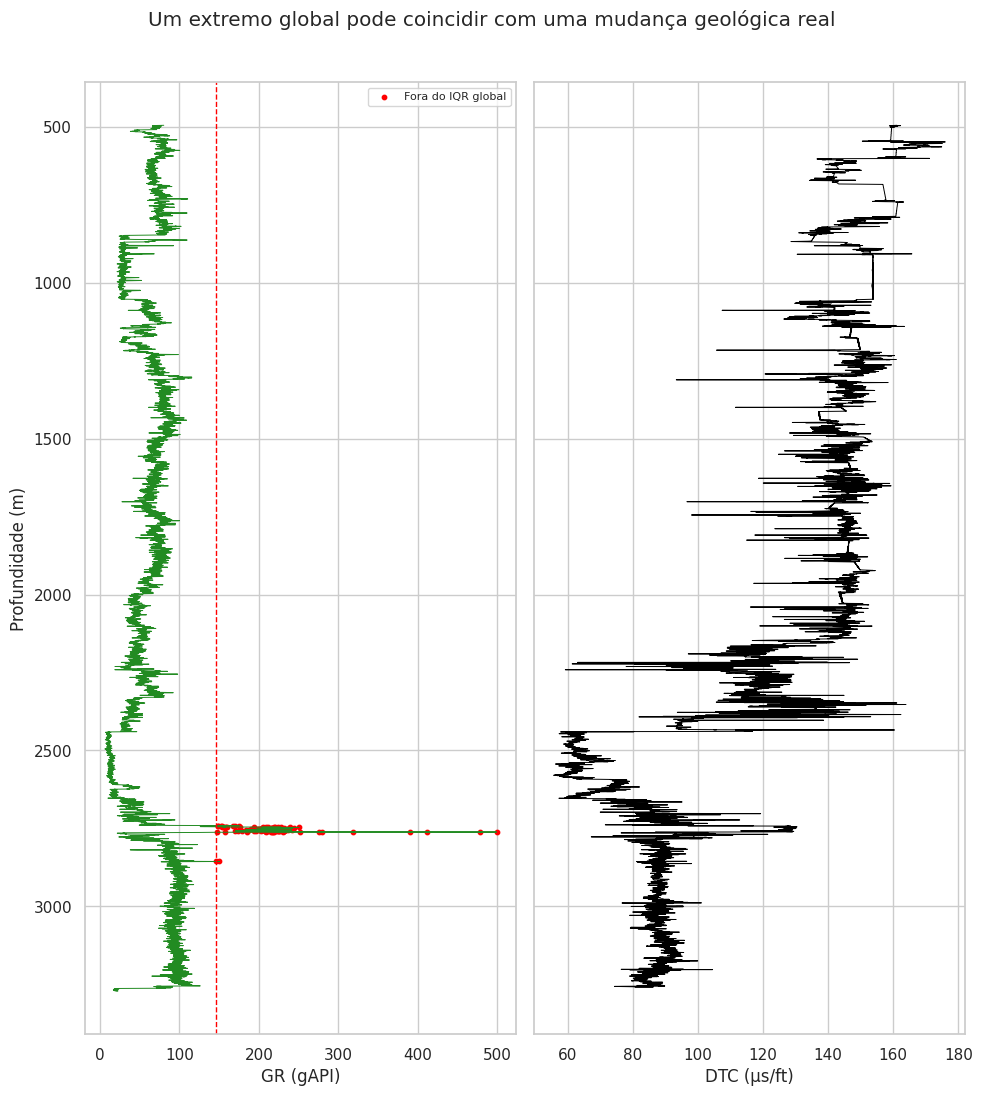

In [18]:
poco_gr = dados.loc[dados["WELL"].eq("15/9-13")].sort_values("DEPTH_MD").copy()
lim_inf_gr, lim_sup_gr = limites_iqr["GR"]
pouco_gr_fora = ~poco_gr["GR"].between(lim_inf_gr, lim_sup_gr)

fig, axes = plt.subplots(1, 2, figsize=(10, 11), sharey=True)
axes[0].plot(poco_gr["GR"], poco_gr["DEPTH_MD"], color="forestgreen", lw=0.7)
axes[0].scatter(
    poco_gr.loc[pouco_gr_fora, "GR"],
    poco_gr.loc[pouco_gr_fora, "DEPTH_MD"],
    color="red",
    s=10,
    label="Fora do IQR global",
)
axes[0].axvline(lim_sup_gr, color="red", ls="--", lw=1)
axes[0].set(xlabel="GR (gAPI)", ylabel="Profundidade (m)")
axes[0].legend(fontsize=8)

axes[1].plot(poco_gr["DTC"], poco_gr["DEPTH_MD"], color="black", lw=0.7)
axes[1].set_xlabel("DTC (µs/ft)")
axes[0].invert_yaxis()
fig.suptitle(
    "Um extremo global pode coincidir com uma mudança geológica real", y=0.995
)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

### Aprofundamento — extremo local com mediana e MAD móvel (**Median Absolute Deviation**)

Perfis são séries ordenadas em profundidade. Comparar uma amostra com sua
vizinhança preserva melhor mudanças regionais do que um único limite global.
A estatística abaixo é uma ferramenta de **triagem**.

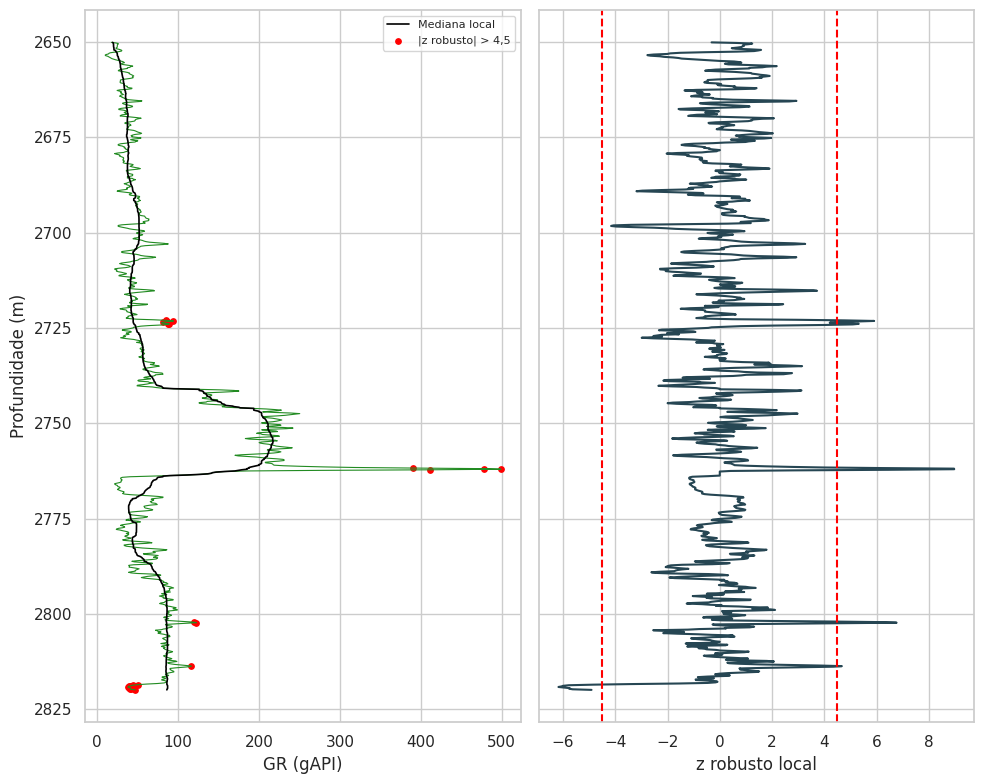

In [19]:
janela = 101
poco_gr["GR_MEDIANA_LOCAL"] = (
    poco_gr["GR"].rolling(janela, center=True, min_periods=25).median()
)
resíduo_local = poco_gr["GR"] - poco_gr["GR_MEDIANA_LOCAL"]
mad_local = (
    resíduo_local.abs().rolling(janela, center=True, min_periods=25).median()
)
poco_gr["Z_ROBUSTO_LOCAL"] = 0.6745 * resíduo_local / mad_local.replace(0, np.nan)
pouco_local = poco_gr["Z_ROBUSTO_LOCAL"].abs() > 4.5

intervalo = poco_gr["DEPTH_MD"].between(2650, 2820)
zoom = poco_gr.loc[intervalo]
flags_zoom = pouco_local.loc[intervalo]

fig, axes = plt.subplots(1, 2, figsize=(10, 8), sharey=True)
axes[0].plot(zoom["GR"], zoom["DEPTH_MD"], color="forestgreen", lw=0.8)
axes[0].plot(
    zoom["GR_MEDIANA_LOCAL"], zoom["DEPTH_MD"],
    color="black", lw=1.2, label="Mediana local",
)
axes[0].scatter(
    zoom.loc[flags_zoom, "GR"],
    zoom.loc[flags_zoom, "DEPTH_MD"],
    color="red", s=15, label="|z robusto| > 4,5",
)
axes[0].set(xlabel="GR (gAPI)", ylabel="Profundidade (m)")
axes[0].legend(fontsize=8)
axes[1].plot(zoom["Z_ROBUSTO_LOCAL"], zoom["DEPTH_MD"], color="#264653")
axes[1].axvline(-4.5, color="red", ls="--")
axes[1].axvline(4.5, color="red", ls="--")
axes[1].set_xlabel("z robusto local")
axes[0].invert_yaxis()
plt.tight_layout()
plt.show()

## 6. QC orientado pelo domínio, mantendo o dado bruto

In [20]:
LIMITES_TRABALHO = {
    "CALI": (5, 30),
    "GR": (0, 300),
    "RHOB": (1.0, 3.2),
    "NPHI": (-0.15, 1.0),
    "DTC": (40, 240),
}

dados_qc = dados.copy()
linhas_qc = []
for curva, (mínimo, máximo) in LIMITES_TRABALHO.items():
    fora = dados_qc[curva].notna() & ~dados_qc[curva].between(mínimo, máximo)
    linhas_qc.append(
        {
            "curva": curva,
            "regra didática": f"{mínimo}–{máximo}",
            "sinalizados": int(fora.sum()),
            "sinalizados_%": 100 * fora.mean(),
        }
    )
    dados_qc.loc[fora, curva] = np.nan

for resistividade in ["RMED", "RDEP"]:
    inválida = dados_qc[resistividade].notna() & (dados_qc[resistividade] <= 0)
    linhas_qc.append(
        {
            "curva": resistividade,
            "regra didática": "> 0",
            "sinalizados": int(inválida.sum()),
            "sinalizados_%": 100 * inválida.mean(),
        }
    )
    dados_qc.loc[inválida, resistividade] = np.nan

pd.DataFrame(linhas_qc).round(3)

,curva,regra didática,sinalizados,sinalizados_%
0,CALI,5–30,860,0.115
1,GR,0–300,823,0.110
2,RHOB,1.0–3.2,31,0.004
3,NPHI,-0.15–1.0,0,0.000
4,DTC,40–240,162,0.022
5,RMED,> 0,7,0.001
6,RDEP,> 0,0,0.000


## 7. Transformações: log da resistividade e escala

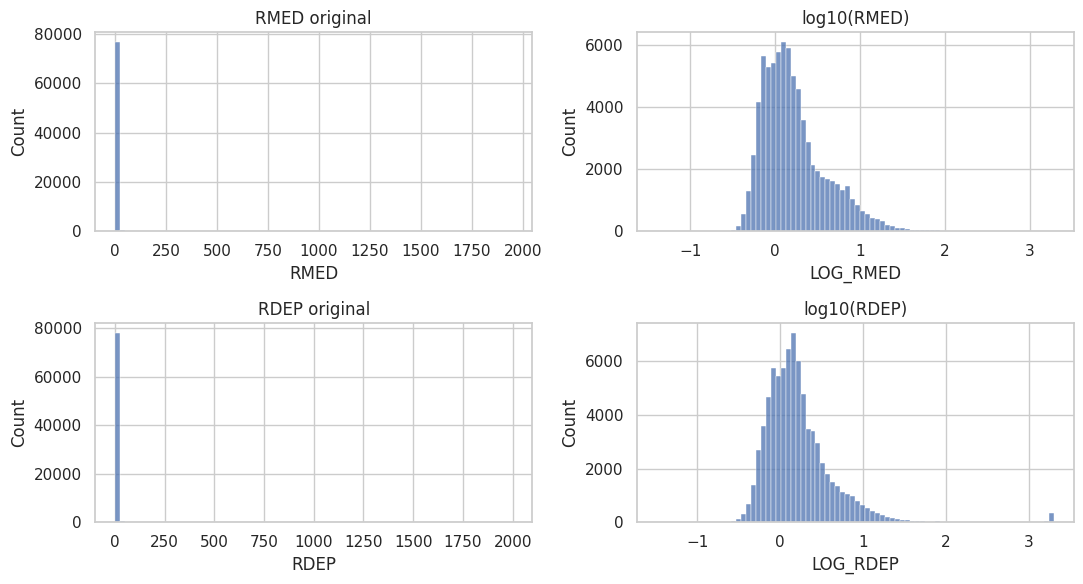

In [21]:
dados_qc["LOG_RMED"] = np.log10(dados_qc["RMED"])
dados_qc["LOG_RDEP"] = np.log10(dados_qc["RDEP"])

amostra_hist = dados_qc.sample(min(80_000, len(dados_qc)), random_state=SEED)
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
sns.histplot(amostra_hist["RMED"], bins=80, ax=axes[0, 0])
sns.histplot(amostra_hist["LOG_RMED"], bins=80, ax=axes[0, 1])
sns.histplot(amostra_hist["RDEP"], bins=80, ax=axes[1, 0])
sns.histplot(amostra_hist["LOG_RDEP"], bins=80, ax=axes[1, 1])
axes[0, 0].set_title("RMED original")
axes[0, 1].set_title("log10(RMED)")
axes[1, 0].set_title("RDEP original")
axes[1, 1].set_title("log10(RDEP)")
plt.tight_layout()
plt.show()

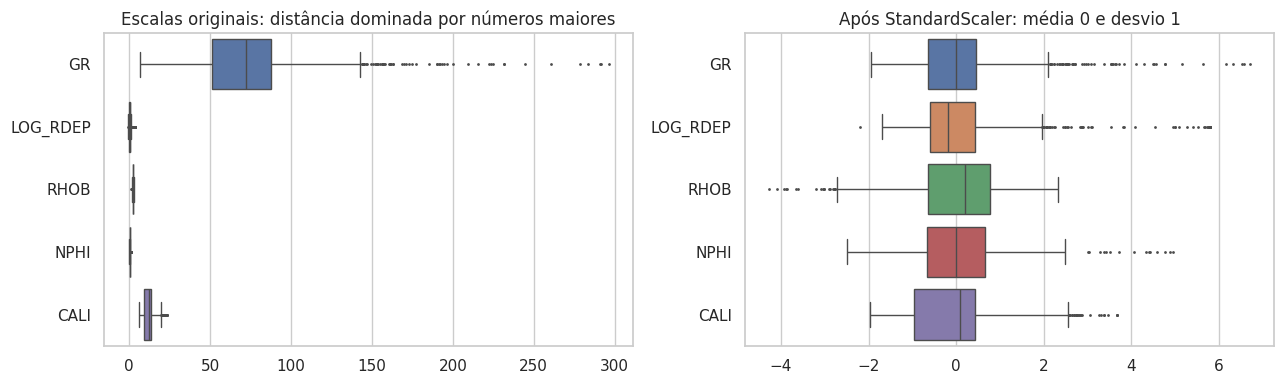

In [22]:
colunas_escala = ["GR", "LOG_RDEP", "RHOB", "NPHI", "CALI"]
exemplo_escala = (
    dados_qc[colunas_escala]
    .dropna()
    .sample(2_000, random_state=SEED)
)
padronizador = StandardScaler()
exemplo_padronizado = pd.DataFrame(
    padronizador.fit_transform(exemplo_escala),
    columns=colunas_escala,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=exemplo_escala, orient="h", ax=axes[0], fliersize=1)
axes[0].set_title("Escalas originais: distância dominada por números maiores")
sns.boxplot(data=exemplo_padronizado, orient="h", ax=axes[1], fliersize=1)
axes[1].set_title("Após StandardScaler: média 0 e desvio 1")
plt.tight_layout()
plt.show()

## 8. Relação entre os preditores e o alvo

Uma correlação baixa não significa ausência de informação: a relação pode ser
não linear, variar entre grupos ou depender da combinação de curvas. Para bases
grandes, `hexbin` mostra densidade melhor que centenas de milhares de pontos
sobrepostos.

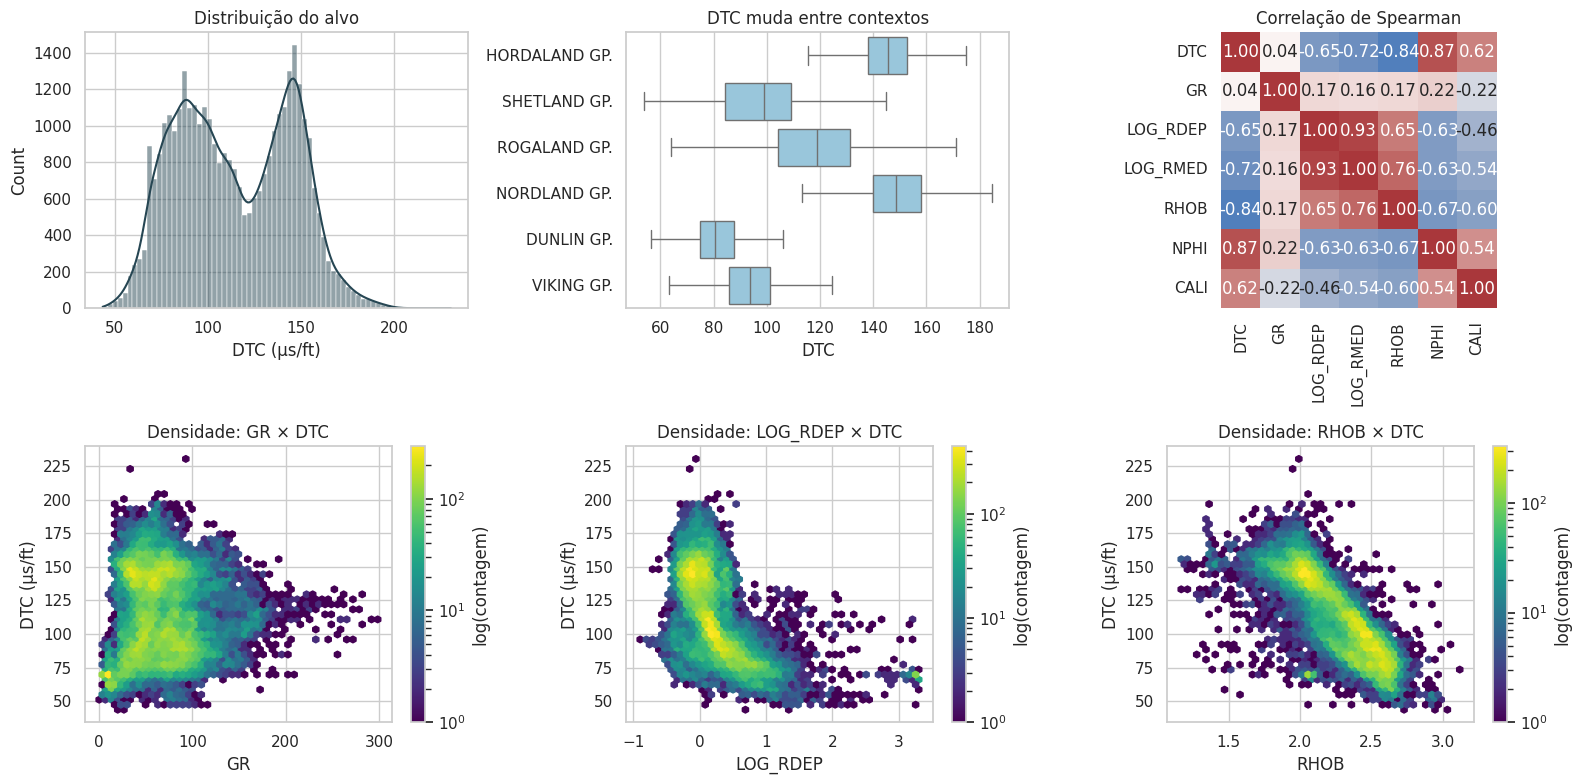

In [23]:
base_relacoes = dados_qc.loc[dados_qc["DTC"].notna()].sample(
    min(35_000, dados_qc["DTC"].notna().sum()),
    random_state=SEED,
)
grupos_frequentes = (
    base_relacoes["GROUP"].value_counts().head(6).index
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
sns.histplot(
    base_relacoes["DTC"], bins=70, kde=True,
    color="#264653", ax=axes[0, 0],
)
axes[0, 0].set_title("Distribuição do alvo")
axes[0, 0].set_xlabel("DTC (µs/ft)")

sns.boxplot(
    data=base_relacoes.loc[base_relacoes["GROUP"].isin(grupos_frequentes)],
    x="DTC", y="GROUP", order=grupos_frequentes,
    showfliers=False, color="#8ecae6", ax=axes[0, 1],
)
axes[0, 1].set_title("DTC muda entre contextos")
axes[0, 1].set_ylabel("")

correlacoes = base_relacoes[
    ["DTC", "GR", "LOG_RDEP", "LOG_RMED", "RHOB", "NPHI", "CALI"]
].corr(method="spearman")
sns.heatmap(
    correlacoes, cmap="vlag", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", square=True, cbar=False, ax=axes[0, 2],
)
axes[0, 2].set_title("Correlação de Spearman")

for ax, atributo in zip(
    axes[1],
    ["GR", "LOG_RDEP", "RHOB"],
):
    parte = base_relacoes[[atributo, "DTC"]].dropna()
    imagem = ax.hexbin(
        parte[atributo], parte["DTC"],
        gridsize=45, mincnt=1, cmap="viridis", bins="log",
    )
    ax.set(
        xlabel=atributo,
        ylabel="DTC (µs/ft)",
        title=f"Densidade: {atributo} × DTC",
    )
    fig.colorbar(imagem, ax=ax, label="log(contagem)")

plt.tight_layout()
plt.show()

- KNN e MLP são muito sensíveis à escala.
- Regressão linear fica numericamente mais estável e seus coeficientes se tornam
  mais comparáveis.
- Árvores e florestas escolhem cortes e não exigem escala.

## 09. Criar a amostra reprodutível da aula

In [24]:
POCO_CEGO = "15/9-13"
ALVO = "DTC"
N_TREINO_AULA = 50_000

treino_pool = dados_qc.loc[
    ~dados_qc["WELL"].eq(POCO_CEGO) & dados_qc[ALVO].notna()
].copy()
poco_cego = dados_qc.loc[dados_qc["WELL"].eq(POCO_CEGO)].copy()

if len(treino_pool) > N_TREINO_AULA:
    treino, _ = train_test_split(
        treino_pool,
        train_size=N_TREINO_AULA,
        random_state=SEED,
        stratify=treino_pool["GROUP"],
    )
else:
    treino = treino_pool

treino["CONJUNTO"] = "treino"
poco_cego["CONJUNTO"] = "poço cego"

colunas_saida = [
    "WELL", "DEPTH_MD", "CALI", "RMED", "RDEP", "RHOB", "GR", "NPHI",
    "DTC", "GROUP", "LITH_CODE", "LITHOLOGY", "LOG_RMED", "LOG_RDEP",
    "CONJUNTO",
]
dados_aula = pd.concat(
    [treino[colunas_saida], poco_cego[colunas_saida]],
    ignore_index=True,
)

pd.DataFrame(
    {
        "linhas": dados_aula.groupby("CONJUNTO").size(),
        "poços": dados_aula.groupby("CONJUNTO")["WELL"].nunique(),
        "DTC conhecido (%)": (
            100
            * dados_aula.groupby("CONJUNTO")["DTC"].apply(
                lambda s: s.notna().mean()
            )
        ).round(1),
    }
)

,linhas,poços,DTC conhecido (%)
CONJUNTO,,,
poço cego,18270,1,99.6
treino,50000,39,100.0


In [25]:
caminho_processado = PASTA_SAIDAS / "dados_regressao_aula.csv"
dados_aula.to_csv(caminho_processado, index=False, float_format="%.6f")

configuração = {
    "seed": SEED,
    "alvo": ALVO,
    "poco_cego": POCO_CEGO,
    "n_treino": int(len(treino)),
    "n_poco_cego": int(len(poco_cego)),
    "fonte": ARQUIVO_DADOS.name,
    "formacao_disponivel": False,
}
(PASTA_SAIDAS / "config_regressao.json").write_text(
    json.dumps(configuração, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"Dados preparados: {caminho_processado}")
print(configuração)

Dados preparados: /content/drive/MyDrive/Curso_Regressao_Pocos/saidas/dados_regressao_aula.csv
{'seed': 42, 'alvo': 'DTC', 'poco_cego': '15/9-13', 'n_treino': 50000, 'n_poco_cego': 18270, 'fonte': 'dataset.csv', 'formacao_disponivel': False}
